### MATH 529L Worksheet 9 - Nathan Day

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, Markdown, Math

In [ ]:
display(Markdown("## Problem 1.1(a)"))
display(Markdown("Let $u(x,t)$ be the probability density of finding a particle at position $x$ at time $t$."))
display(Markdown("If after a time step $\\tau$ the particle moves left or right by distance $h$ with equal probability, then:"))
display(Math(r"u(x,t+\tau)=\frac12\,u(x-h,t)+\frac12\,u(x+h,t)"))

## Problem 1.1(a)

Let $u(x,t)$ be the probability density of finding a particle at position $x$ at time $t$.

If after a time step $\tau$ the particle moves left or right by distance $h$ with equal probability, then:

<IPython.core.display.Math object>

In [ ]:
display(Markdown("## Problem 1.1(b)"))
display(Markdown("Apply a second-order Taylor expansion in time and space."))

display(Math(r"u(x,t+\tau)=u(x,t)+\tau u_t(x,t)+O(\tau^2)"))

display(Math(r"u(x+h,t)=u(x,t)+h\,u_x(x,t)+\frac{h^2}{2}u_{xx}(x,t)+O(h^3)"))

display(Math(r"u(x-h,t)=u(x,t)-h\,u_x(x,t)+\frac{h^2}{2}u_{xx}(x,t)+O(h^3)"))

display(Markdown("Substitute into the random walk formula:"))
display(Math(r"u(x,t)+\tau u_t(x,t)=\frac12\left(u-hu_x+\frac{h^2}{2}u_{xx}\right)+\frac12\left(u+hu_x+\frac{h^2}{2}u_{xx}\right)"))

display(Markdown("The first-derivative terms cancel, so:"))
display(Math(r"u(x,t)+\tau u_t(x,t)=u(x,t)+\frac{h^2}{2}u_{xx}(x,t)"))

## Problem 1.1(b)

Apply a second-order Taylor expansion in time and space.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Substitute into the random walk formula:

<IPython.core.display.Math object>

The first-derivative terms cancel, so:

<IPython.core.display.Math object>

In [ ]:
display(Markdown("## Problem 1.1(c)"))
display(Markdown("Subtract $u(x,t)$ from both sides and divide by $\\tau$:"))
display(Math(r"u_t=\frac{h^2}{2\tau}u_{xx}"))

display(Markdown("Define"))
display(Math(r"D=\frac{h^2}{2\tau}"))

display(Markdown("so the diffusion equation is"))
display(Math(r"u_t = D\,u_{xx}"))

## Problem 1.1(c)

Subtract $u(x,t)$ from both sides and divide by $\tau$:

<IPython.core.display.Math object>

Define

<IPython.core.display.Math object>

so the diffusion equation is

<IPython.core.display.Math object>

In [ ]:
display(Markdown("## Problem 1.2"))
display(Markdown("We solve the boundary value problem"))
display(Math(r"u''(x)=0,\qquad x\in[0,1],\qquad u(0)=0,\quad u(1)=1"))
display(Markdown("The exact solution is"))
display(Math(r"u(x)=x"))

## Problem 1.2

We solve the boundary value problem

<IPython.core.display.Math object>

The exact solution is

<IPython.core.display.Math object>

In [ ]:
L = 1.0
a = 0.0
b = 1.0
h = 0.01

xgrid = np.arange(0, L + h, h)

def monte_carlo_1d(Nwalks, L=1.0, a=0.0, b=1.0, h=0.01):
    xgrid = np.arange(0, L + h, h)
    Umc = np.zeros_like(xgrid)
    Umc[0] = a
    Umc[-1] = b

    for k in range(1, len(xgrid)-1):
        x0 = xgrid[k]
        vals = np.zeros(Nwalks)

        for n in range(Nwalks):
            x = x0
            while True:
                if x <= 0:
                    vals[n] = a
                    break
                elif x >= L:
                    vals[n] = b
                    break

                if np.random.rand() < 0.5:
                    x = x - h
                else:
                    x = x + h

        Umc[k] = np.mean(vals)

    return xgrid, Umc

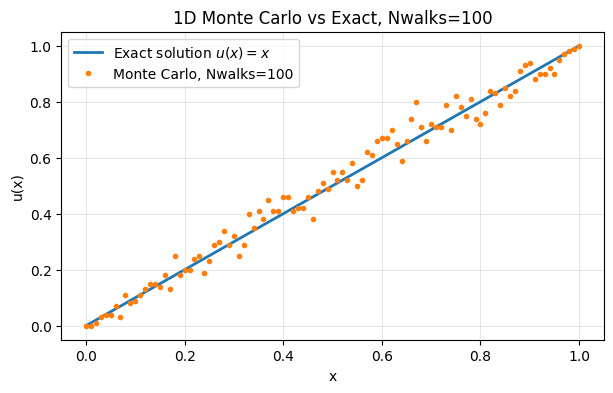

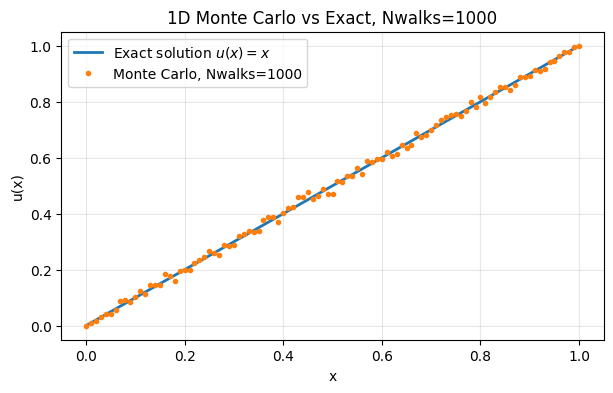

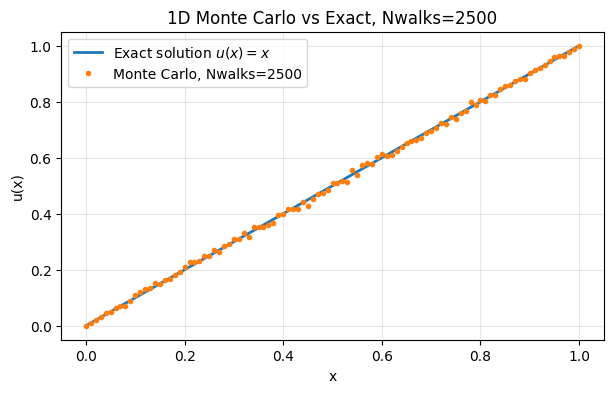

In [ ]:
walk_list = [100, 1000, 2500]
exact = xgrid

results_1d = []

for Nwalks in walk_list:
    start = time.time()
    xgrid, Umc = monte_carlo_1d(Nwalks, L=L, a=a, b=b, h=h)
    runtime = time.time() - start
    error = np.max(np.abs(Umc - xgrid))
    results_1d.append((Nwalks, runtime, error, Umc))

    plt.figure(figsize=(7,4))
    plt.plot(xgrid, xgrid, linewidth=2, label="Exact solution $u(x)=x$")
    plt.plot(xgrid, Umc, 'o', markersize=3, label=f"Monte Carlo, Nwalks={Nwalks}")
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.title(f"1D Monte Carlo vs Exact, Nwalks={Nwalks}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
display(Markdown("### Discussion for Problem 1.2"))

for Nwalks, runtime, error, Umc in results_1d:
    display(Markdown(
        f"- For **Nwalks = {Nwalks}**, runtime was **{runtime:.2f} s** and the max error was about **{error:.4f}**."
    ))

display(Markdown(
    "As the number of walks increases, the Monte Carlo solution becomes less noisy and agrees better with the exact linear solution $u(x)=x$. "
    "However, increasing the number of walks also increases the computational time, since more random trajectories must be simulated at every grid point."
))

### Discussion for Problem 1.2

- For **Nwalks = 100**, runtime was **16.38 s** and the max error was about **0.1300**.

- For **Nwalks = 1000**, runtime was **162.18 s** and the max error was about **0.0310**.

- For **Nwalks = 2500**, runtime was **369.68 s** and the max error was about **0.0240**.

As the number of walks increases, the Monte Carlo solution becomes less noisy and agrees better with the exact linear solution $u(x)=x$. However, increasing the number of walks also increases the computational time, since more random trajectories must be simulated at every grid point.

In [ ]:
display(Markdown("## Problem 1.3(a)"))

display(Markdown("Let $u(x,y,t)$ be the probability density of finding a particle at $(x,y)$ at time $t$."))
display(Markdown("If after one time step $\\tau$ the particle moves left, right, up, or down by distance $h$ with equal probability, then"))
display(Math(r"u(x,y,t+\tau)=\frac14 u(x-h,y,t)+\frac14 u(x+h,y,t)+\frac14 u(x,y-h,t)+\frac14 u(x,y+h,t)"))

## Problem 1.3(a)

Let $u(x,y,t)$ be the probability density of finding a particle at $(x,y)$ at time $t$.

If after one time step $\tau$ the particle moves left, right, up, or down by distance $h$ with equal probability, then

<IPython.core.display.Math object>

In [ ]:
display(Markdown("## Problem 1.3(b)"))

display(Math(r"u(x,y,t+\tau)=u(x,y,t)+\tau u_t(x,y,t)+O(\tau^2)"))

display(Math(r"u(x\pm h,y,t)=u(x,y,t)\pm h u_x(x,y,t)+\frac{h^2}{2}u_{xx}(x,y,t)+O(h^3)"))

display(Math(r"u(x,y\pm h,t)=u(x,y,t)\pm h u_y(x,y,t)+\frac{h^2}{2}u_{yy}(x,y,t)+O(h^3)"))

display(Markdown("Substitute into the four-direction random walk formula. The first-derivative terms cancel, leaving"))
display(Math(r"u(x,y,t)+\tau u_t(x,y,t)=u(x,y,t)+\frac{h^2}{4}\left(u_{xx}(x,y,t)+u_{yy}(x,y,t)\right)"))

## Problem 1.3(b)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Substitute into the four-direction random walk formula. The first-derivative terms cancel, leaving

<IPython.core.display.Math object>

In [ ]:
display(Markdown("## Problem 1.3(c)"))

display(Markdown("Subtract $u(x,y,t)$ and divide by $\\tau$:"))
display(Math(r"u_t=\frac{h^2}{4\tau}(u_{xx}+u_{yy})"))

display(Markdown("Define"))
display(Math(r"D=\frac{h^2}{4\tau}"))

display(Markdown("so the 2D diffusion equation is"))
display(Math(r"u_t = D(u_{xx}+u_{yy})"))

## Problem 1.3(c)

Subtract $u(x,y,t)$ and divide by $\tau$:

<IPython.core.display.Math object>

Define

<IPython.core.display.Math object>

so the 2D diffusion equation is

<IPython.core.display.Math object>

In [ ]:
# Problem 1.3(d): 2D Monte Carlo solution of Laplace's equation

L = 1.0
h = 0.05

xgrid = np.arange(0, L + h, h)
ygrid = np.arange(0, L + h, h)

Nx = len(xgrid)
Ny = len(ygrid)

Nwalks = 1000

Umc = np.zeros((Nx, Ny))

# Boundary values
# bottom edge y=0
Umc[:, 0] = 0.0

# top edge y=L
Umc[:, Ny-1] = 1.0

# left edge x=0
Umc[0, :] = 0.0

# right edge x=L
Umc[Nx-1, :] = 0.0

# corner values on the top wall
Umc[0, Ny-1] = 0.0      # top-left corner
Umc[Nx-1, Ny-1] = 0.0   # top-right corner

for i0 in range(1, Nx-1):
    for j0 in range(1, Ny-1):

        vals = np.zeros(Nwalks)

        for n in range(Nwalks):
            i = i0
            j = j0

            while True:
                if j == 0:
                    vals[n] = 0.0    # bottom
                    break
                elif j == Ny-1:
                    vals[n] = 1.0    # top
                    break
                elif i == 0:
                    vals[n] = 0.0    # left
                    break
                elif i == Nx-1:
                    vals[n] = 0.0    # right
                    break

                r = np.random.randint(4)
                if r == 0:
                    i = i + 1   # right
                elif r == 1:
                    i = i - 1   # left
                elif r == 2:
                    j = j + 1   # up
                else:
                    j = j - 1   # down

        Umc[i0, j0] = np.mean(vals)

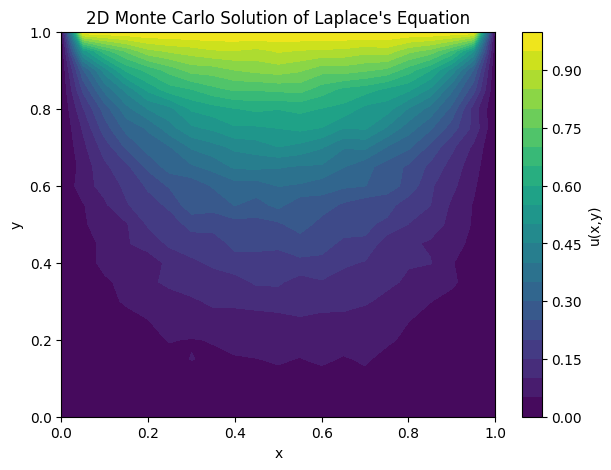

In [ ]:
X, Y = np.meshgrid(xgrid, ygrid, indexing='ij')

plt.figure(figsize=(7,5))
plt.contourf(X, Y, Umc, levels=20)
plt.colorbar(label="u(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Monte Carlo Solution of Laplace's Equation")
plt.show()

In [ ]:
display(Markdown("## Problem 1.4"))
display(Markdown("We solve the two-dimensional heat equation on the unit square with zero Dirichlet boundary conditions."))

display(Math(r"u_t = D(u_{xx}+u_{yy}), \qquad (x,y)\in[0,1]\times[0,1]"))

display(Markdown("Initial condition: a centered Gaussian bump"))
display(Math(r"u_0(x,y)=\exp\left(-\frac{(x-x_c)^2+(y-y_c)^2}{2\sigma^2}\right)"))

## Problem 1.4

We solve the two-dimensional heat equation on the unit square with zero Dirichlet boundary conditions.

<IPython.core.display.Math object>

Initial condition: a centered Gaussian bump

<IPython.core.display.Math object>

In [ ]:
# Problem 1.4: 2D heat equation via Brownian motion

L = 1.0
D = 1.0

Nx = 61
Ny = 61
xgrid = np.linspace(0, L, Nx)
ygrid = np.linspace(0, L, Ny)
dx = xgrid[1] - xgrid[0]
dy = ygrid[1] - ygrid[0]

X, Y = np.meshgrid(xgrid, ygrid, indexing='xy')

Tfinal = 0.05
dt = 0.0005
Nsteps = int(np.ceil(Tfinal / dt))
dt = Tfinal / Nsteps
BrownianProcess = np.sqrt(2 * D * dt)

Nparticles = 30000

# Initial Gaussian bump
xc = 0.5
yc = 0.5
sigma = 0.1

u0 = lambda x, y: np.exp(-((x - xc)**2 + (y - yc)**2) / (2 * sigma**2))
U0 = u0(X, Y)

# Sample initial particle positions from u0
mass0 = np.sum(U0) * dx * dy
prob0 = U0.ravel() / np.sum(U0)

idx = np.random.choice(np.arange(U0.size), size=Nparticles, replace=True, p=prob0)
j0, i0 = np.unravel_index(idx, U0.shape)

xp = xgrid[i0] + dx * (np.random.rand(Nparticles) - 0.5)
yp = ygrid[j0] + dy * (np.random.rand(Nparticles) - 0.5)

xp = np.clip(xp, 0, L)
yp = np.clip(yp, 0, L)

In [ ]:
# Times we want snapshots for:
snapshot_times = [0.0, 0.015, 0.03, Tfinal]
snapshot_steps = [int(round(t / dt)) for t in snapshot_times]

snapshots = {}

# Initial snapshot
edgesX = np.linspace(0, L, Nx+1)
edgesY = np.linspace(0, L, Ny+1)

H0, _, _ = np.histogram2d(yp, xp, bins=[edgesY, edgesX])
snapshots[0.0] = (mass0 / Nparticles) * H0 / (dx * dy)

alive = np.ones(Nparticles, dtype=bool)

for n in range(1, Nsteps + 1):
    if not np.any(alive):
        break

    xp[alive] = xp[alive] + BrownianProcess * np.random.randn(np.sum(alive))
    yp[alive] = yp[alive] + BrownianProcess * np.random.randn(np.sum(alive))

    # zero Dirichlet boundary conditions = kill particles that leave the square
    alive = alive & (xp > 0) & (xp < L) & (yp > 0) & (yp < L)

    if n in snapshot_steps:
        xp_now = xp[alive]
        yp_now = yp[alive]
        H, _, _ = np.histogram2d(yp_now, xp_now, bins=[edgesY, edgesX])
        snapshots[n * dt] = (mass0 / Nparticles) * H / (dx * dy)

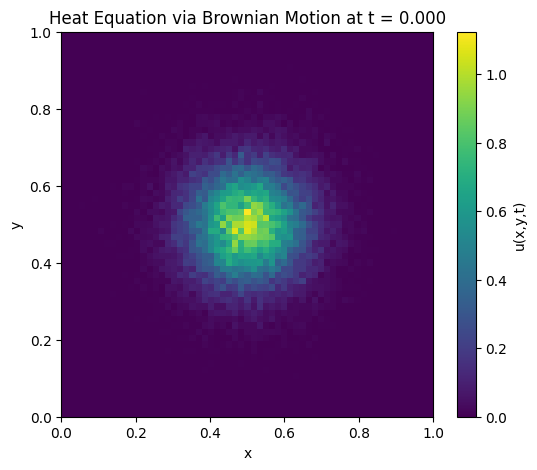

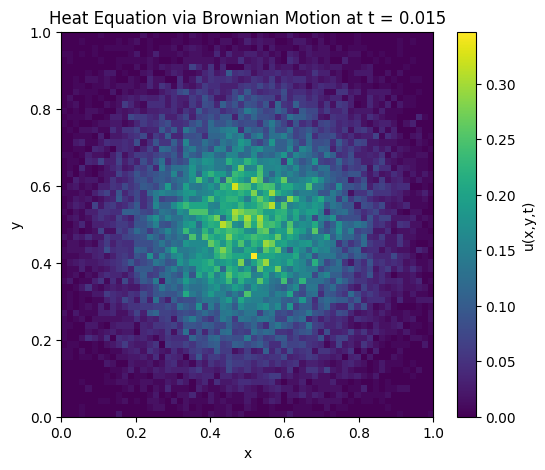

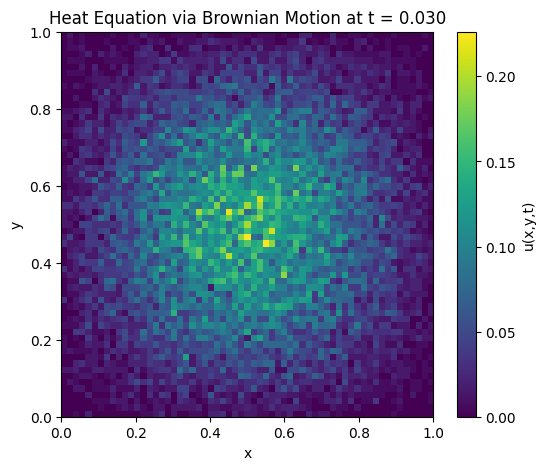

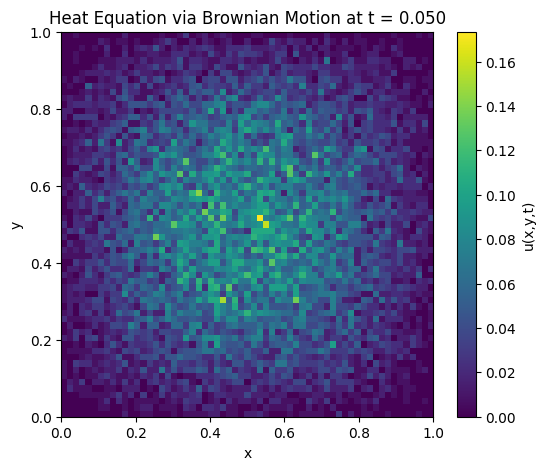

In [ ]:
plot_times = sorted(snapshots.keys())

for t in plot_times:
    Uplot = snapshots[t]

    plt.figure(figsize=(6,5))
    plt.imshow(Uplot, origin='lower', extent=[0, L, 0, L], aspect='auto')
    plt.colorbar(label="u(x,y,t)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Heat Equation via Brownian Motion at t = {t:.3f}")
    plt.show()

In [ ]:
display(Markdown("### Discussion for Problem 1.4"))

display(Markdown(
    "The initial condition starts as a Gaussian bump centered in the square. "
    "As time increases, diffusion spreads the mass outward while the zero Dirichlet boundaries absorb particles that hit the walls. "
    "Because of this absorption, the total mass decreases over time and the solution approaches the steady state $u(x,y,t)\\to 0$."
))

### Discussion for Problem 1.4

The initial condition starts as a Gaussian bump centered in the square. As time increases, diffusion spreads the mass outward while the zero Dirichlet boundaries absorb particles that hit the walls. Because of this absorption, the total mass decreases over time and the solution approaches the steady state $u(x,y,t)\to 0$.

In [ ]:
display(Markdown("## Problem 1.4(2): How to program Neumann boundary conditions"))

display(Markdown(
    "To impose Neumann boundary conditions in the Monte Carlo method, we would **reflect particles at the boundary instead of killing them**. "
    "For example, if a particle steps past the left wall, we would move it back into the domain by reflecting its position across the wall. "
    "This models zero normal flux through the boundary, meaning particles do not leave the domain. "
    "So Dirichlet conditions are implemented by absorbing particles at the wall, while Neumann conditions are implemented by reflecting particles at the wall."
))

## Problem 1.4(2): How to program Neumann boundary conditions

To impose Neumann boundary conditions in the Monte Carlo method, we would **reflect particles at the boundary instead of killing them**. For example, if a particle steps past the left wall, we would move it back into the domain by reflecting its position across the wall. This models zero normal flux through the boundary, meaning particles do not leave the domain. So Dirichlet conditions are implemented by absorbing particles at the wall, while Neumann conditions are implemented by reflecting particles at the wall.